Epoch 0, Loss: 0.4993
Epoch 2000, Loss: 0.4996
Epoch 4000, Loss: 0.4930
Epoch 6000, Loss: 0.3581
Epoch 8000, Loss: 0.1262

Final Predictions:
Input: [0 0] => Output: 0.0787
Input: [0 1] => Output: 0.9255
Input: [1 0] => Output: 0.9272
Input: [1 1] => Output: 0.0797


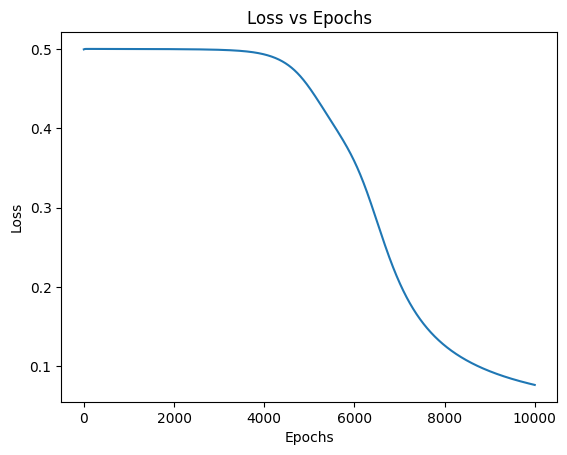

In [1]:
# ===================================
# XOR using Backpropagation
# ===================================
import numpy as np
import matplotlib.pyplot as plt

# ===================================
# 1. Activation Function
# ===================================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# ===================================
# 2. XOR Dataset (as per manual)
# ===================================
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

# ===================================
# 3. Initialize weights and bias
# ===================================
np.random.seed(1)

w1 = np.random.rand(2, 4)   # input → hidden
w2 = np.random.rand(4, 1)   # hidden → output

b1 = np.zeros((1, 4))
b2 = np.zeros((1, 1))

# ===================================
# 4. Training
# ===================================
epochs = 10000
lr = 0.1
losses = []

for epoch in range(epochs):

    # ---------- Forward Propagation ----------
    z1 = np.dot(X, w1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, w2) + b2
    a2 = sigmoid(z2)

    # ---------- Error ----------
    error = y - a2
    losses.append(np.mean(np.abs(error)))

    # ---------- Backpropagation ----------
    d2 = error * sigmoid_derivative(a2)
    d1 = d2.dot(w2.T) * sigmoid_derivative(a1)

    # ---------- Update ----------
    w2 += a1.T.dot(d2) * lr
    w1 += X.T.dot(d1) * lr

    b2 += np.sum(d2, axis=0, keepdims=True) * lr
    b1 += np.sum(d1, axis=0, keepdims=True) * lr

    # Print loss
    if epoch % 2000 == 0:
        print(f"Epoch {epoch}, Loss: {losses[-1]:.4f}")

# ===================================
# 5. Testing
# ===================================
print("\nFinal Predictions:")

for i in range(len(X)):
    hidden = sigmoid(np.dot(X[i], w1) + b1)
    output = sigmoid(np.dot(hidden, w2) + b2)
    
    print(f"Input: {X[i]} => Output: {output[0][0]:.4f}")

# ===================================
# 6. Loss Graph (MANDATORY for marks)
# ===================================
plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()